In [1]:
import torch
import torchvision
import torch.utils.data
import torchvision.transforms.v2

transforms = torchvision.transforms.v2.Compose(
    [
        torchvision.transforms.v2.Resize(224),
        torchvision.transforms.v2.Grayscale(num_output_channels=3),
        torchvision.transforms.v2.ToImage(),
        torchvision.transforms.v2.ToDtype(torch.float32, scale=True),
        torchvision.transforms.v2.Normalize((0.1307,), (0.3081,)),
    ]
)
train_ds = torchvision.datasets.MNIST("mnist", train=True, download=True, transform=transforms)
test_ds = torchvision.datasets.MNIST("mnist", train=False, download=True, transform=transforms)
classes = train_ds.class_to_idx

K_NEIGHBORS = 4
MAX_DIMENSION = 3

In [ ]:
import zigzag.nn
import zigzag.utils

dumper = zigzag.utils.UniversalDumper("mnist/resnet_small")

model = torchvision.models.resnet18(
    num_classes=1000, weights=torchvision.models.ResNet18_Weights.DEFAULT
)
model.fc = torch.nn.Identity()

train_embeddings = dumper.execute(
    zigzag.nn.precompute_embeddings,
    "train_embeddings",
    model,
    torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=False, num_workers=3)
)
test_embeddings = dumper.execute(
    zigzag.nn.precompute_embeddings,
    "test_embeddings",
    model,
    torch.utils.data.DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=3)
)

Got the result from mnist/resnet_small/train_embeddings.pt
Got the result from mnist/resnet_small/test_embeddings.pt


In [3]:
train_emb_ds = torch.utils.data.TensorDataset(train_embeddings, train_ds.targets)
test_emb_ds = torch.utils.data.TensorDataset(test_embeddings, test_ds.targets)

head = torch.nn.Sequential(torch.nn.LazyLinear(len(classes)), torch.nn.Softmax(dim=1))
train_history = dumper.execute(
    zigzag.nn.train,
    "train_history",
    head,
    torch.utils.data.DataLoader(train_emb_ds, batch_size=128, shuffle=True, num_workers=3),
    torch.utils.data.DataLoader(test_emb_ds, batch_size=128, shuffle=False, num_workers=3),
)

Got the result from mnist/resnet_small/train_history.csv


/usr/local/lib/python3.12/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [4]:
train_img_ds = torch.utils.data.Subset(train_ds, indices=range(1000))

hidden_states = dumper.execute(
    zigzag.nn.collect_hidden_states,
    "hidden_states",
    model,
    torch.utils.data.DataLoader(train_img_ds, batch_size=128, shuffle=False, num_workers=3)
)
num_layers = len(hidden_states)

Got the result from mnist/resnet_small/hidden_states
Got the result from mnist/resnet_small/hidden_states/0.pt
Got the result from mnist/resnet_small/hidden_states/1.pt
Got the result from mnist/resnet_small/hidden_states/2.pt
Got the result from mnist/resnet_small/hidden_states/3.pt
Got the result from mnist/resnet_small/hidden_states/4.pt
Got the result from mnist/resnet_small/hidden_states/5.pt
Got the result from mnist/resnet_small/hidden_states/6.pt
Got the result from mnist/resnet_small/hidden_states/7.pt
Got the result from mnist/resnet_small/hidden_states/8.pt


In [10]:
import zigzag.topology

knn_graphs = dumper.execute(
    zigzag.topology.make_knn_graphs_vector,
    "vectors/knn_graphs",
    hidden_states,
    k_neighbors=K_NEIGHBORS
)
diagrams = dumper.execute(
    zigzag.topology.compute_zigzag_barcodes,
    "vectors/diagrams",
    knn_graphs,
    dimension=MAX_DIMENSION
)

KNN graphs: 100%|██████████| 9/9 [00:29<00:00,  3.25s/it]


Saving the result to mnist/resnet_small/vectors/knn_graphs
Saving the result to mnist/resnet_small/vectors/knn_graphs/0.npz
Saving the result to mnist/resnet_small/vectors/knn_graphs/1.npz
Saving the result to mnist/resnet_small/vectors/knn_graphs/2.npz
Saving the result to mnist/resnet_small/vectors/knn_graphs/3.npz
Saving the result to mnist/resnet_small/vectors/knn_graphs/4.npz
Saving the result to mnist/resnet_small/vectors/knn_graphs/5.npz
Saving the result to mnist/resnet_small/vectors/knn_graphs/6.npz
Saving the result to mnist/resnet_small/vectors/knn_graphs/7.npz
Saving the result to mnist/resnet_small/vectors/knn_graphs/8.npz


Generate simplex tree: 100%|██████████| 9/9 [00:00<00:00, 78.35it/s]


[======================================================================] 100%
Saving the result to mnist/resnet_small/vectors/diagrams
Saving the result to mnist/resnet_small/vectors/diagrams/0.npy
Saving the result to mnist/resnet_small/vectors/diagrams/1.npy
Saving the result to mnist/resnet_small/vectors/diagrams/2.npy
Saving the result to mnist/resnet_small/vectors/diagrams/3.npy


/Users/abramov-alex/Desktop/HSE/CourseProject-Mag-1/zigzag/topology/plotting.py:45: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow(numpy.log10(pis_pers), cmap=CMAP, origin="lower")


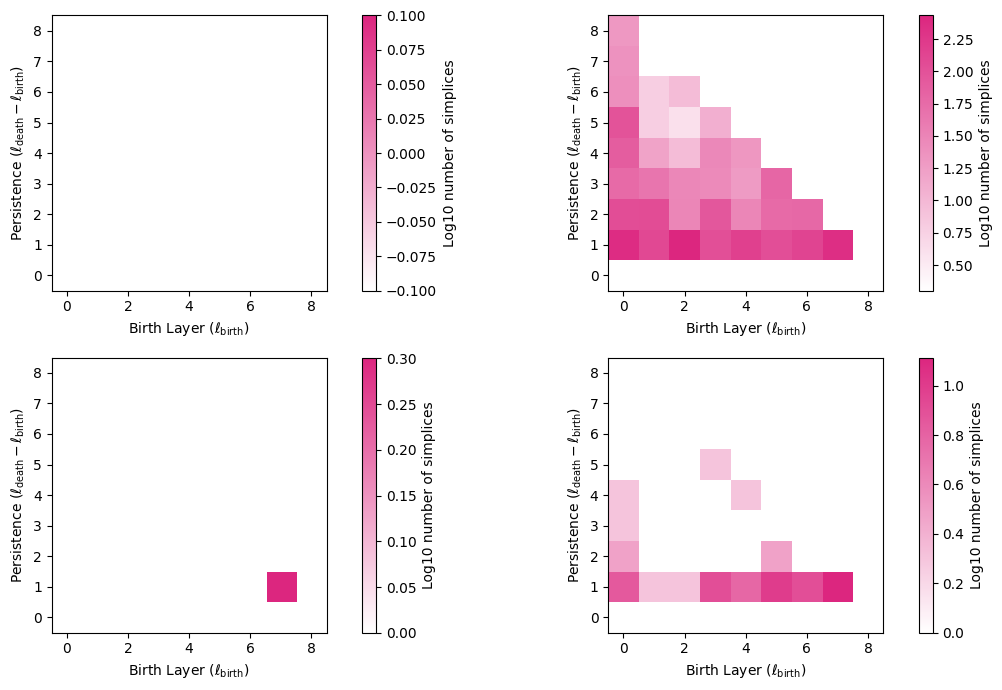

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_persistence_image(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/persistence_image.png")
fig.savefig(f"{dumper.directory_}/persistence_image.svg")

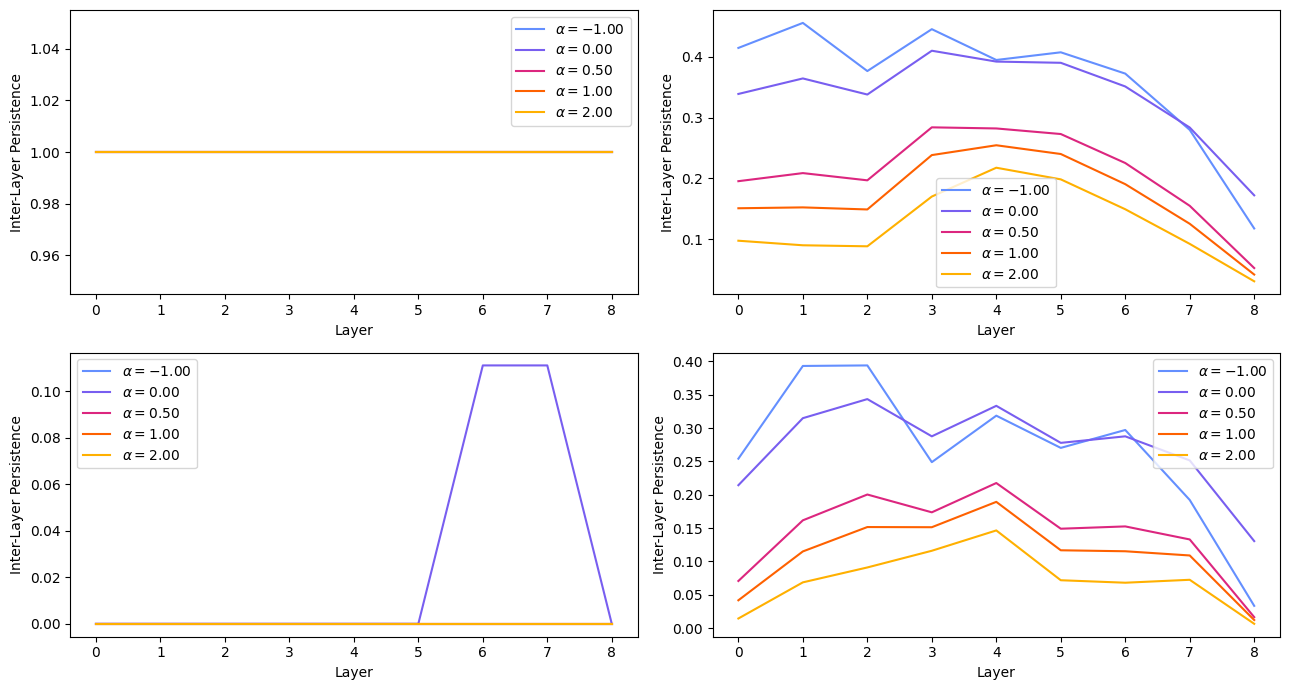

In [12]:
fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_weighted_inter_layer_persistence(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/inter_layer_persistence.png")
fig.savefig(f"{dumper.directory_}/inter_layer_persistence.svg")

/Users/abramov-alex/Desktop/HSE/CourseProject-Mag-1/zigzag/topology/metrics.py:80: RuntimeWarning: invalid value encountered in divide
  return result / numpy.sum(result)


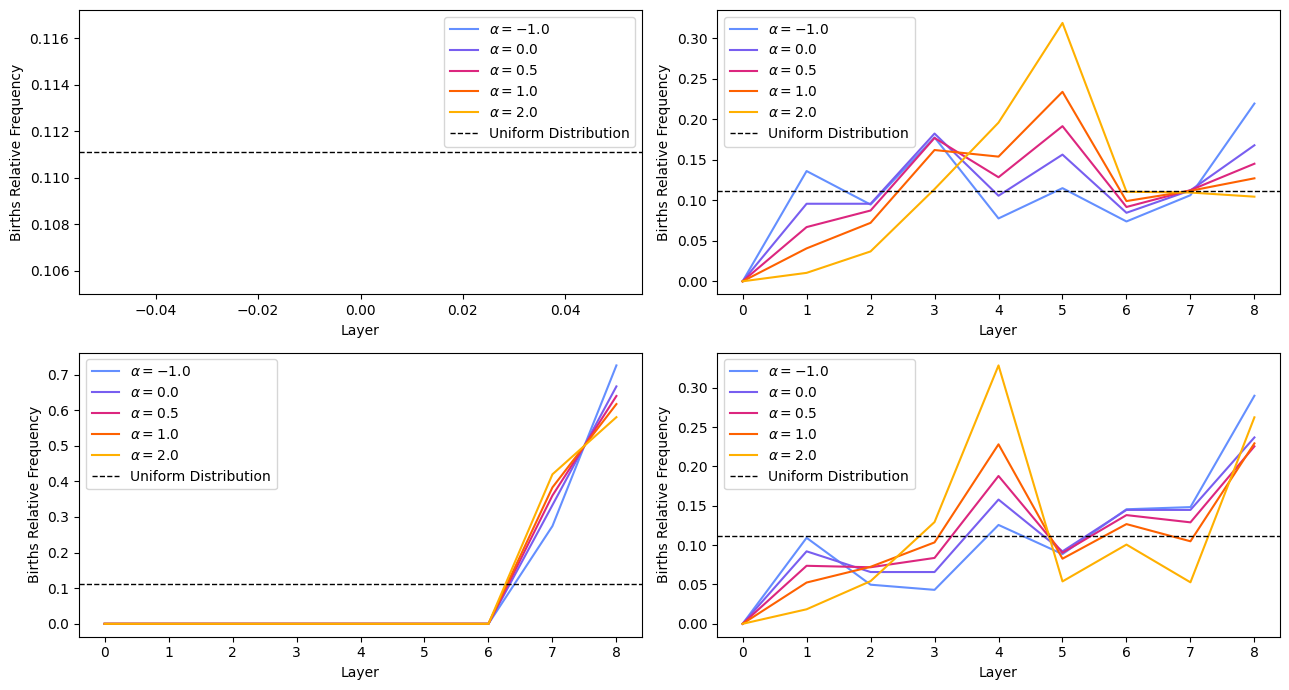

In [13]:
fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_births_relative_frequency(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/births_relative_frequency.png")
fig.savefig(f"{dumper.directory_}/births_relative_frequency.svg")

In [15]:
import zigzag.topology

persistence_diagrams = dumper.execute(
    zigzag.topology.make_cubical_persistence,
    "persistence_diagrams",
    hidden_states
)
knn_graphs = dumper.execute(
    zigzag.topology.make_knn_graphs_pds,
    "landscape/knn_graphs",
    persistence_diagrams,
    k_neighbors=K_NEIGHBORS,
    metric='landscape'
)
diagrams = dumper.execute(
    zigzag.topology.compute_zigzag_barcodes,
    "landscape/diagrams",
    knn_graphs,
    dimension=MAX_DIMENSION
)

Got the result from mnist/resnet_small/persistence_diagrams
Got the result from mnist/resnet_small/persistence_diagrams/0.npy
Got the result from mnist/resnet_small/persistence_diagrams/1.npy
Got the result from mnist/resnet_small/persistence_diagrams/2.npy
Got the result from mnist/resnet_small/persistence_diagrams/3.npy
Got the result from mnist/resnet_small/persistence_diagrams/4.npy
Got the result from mnist/resnet_small/persistence_diagrams/5.npy
Got the result from mnist/resnet_small/persistence_diagrams/6.npy
Got the result from mnist/resnet_small/persistence_diagrams/7.npy
Got the result from mnist/resnet_small/persistence_diagrams/8.npy


KNN graphs:  22%|██▏       | 2/9 [00:04<00:16,  2.35s/it]/usr/local/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
KNN graphs:  44%|████▍     | 4/9 [00:08<00:09,  1.89s/it]/usr/local/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
KNN graphs:  78%|███████▊  | 7/9 [00:09<00:01,  1.06it/s]/usr/local/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
KNN graphs: 100%|██████████| 9/9 [00:11<00:00,  1.29s/it]


Saving the result to mnist/resnet_small/landscape/knn_graphs
Saving the result to mnist/resnet_small/landscape/knn_graphs/0.npz
Saving the result to mnist/resnet_small/landscape/knn_graphs/1.npz
Saving the result to mnist/resnet_small/landscape/knn_graphs/2.npz
Saving the result to mnist/resnet_small/landscape/knn_graphs/3.npz
Saving the result to mnist/resnet_small/landscape/knn_graphs/4.npz
Saving the result to mnist/resnet_small/landscape/knn_graphs/5.npz
Saving the result to mnist/resnet_small/landscape/knn_graphs/6.npz
Saving the result to mnist/resnet_small/landscape/knn_graphs/7.npz
Saving the result to mnist/resnet_small/landscape/knn_graphs/8.npz


Generate simplex tree: 100%|██████████| 9/9 [00:00<00:00, 28.86it/s]


[======================================================================] 100%
Saving the result to mnist/resnet_small/landscape/diagrams
Saving the result to mnist/resnet_small/landscape/diagrams/0.npy
Saving the result to mnist/resnet_small/landscape/diagrams/1.npy
Saving the result to mnist/resnet_small/landscape/diagrams/2.npy
Saving the result to mnist/resnet_small/landscape/diagrams/3.npy


In [32]:
import gtda.diagrams
a = gtda.diagrams.PairwiseDistance(metric='landscape', n_jobs=-1).fit_transform(persistence_diagrams[0])
b = gtda.diagrams.PairwiseDistance(metric='landscape', n_jobs=-1).fit_transform(persistence_diagrams[1])

In [ ]:
numpy.argsort(a[0])

array([  0, 801, 281, 157, 164, 179, 867, 224, 361, 152, 991, 180, 809,
       842,  35, 228, 297, 187, 624, 983, 248, 557, 270, 920, 266, 321,
       397,  25, 835, 332, 443, 768, 215, 257, 982, 570, 490, 852, 538,
       747, 115,  10, 417,  28, 682, 964, 897, 314, 553, 290, 161, 306,
       926, 833, 486, 795, 981, 450, 454, 480, 497, 729, 711, 715, 714,
       826, 845, 933, 840, 914,  27, 730, 475, 554,  98, 581, 286, 625,
       871, 254, 805, 344, 659, 966, 789, 837, 149, 363, 637, 447, 677,
       193, 105, 523, 495,  74, 828, 466, 688, 237, 365, 242, 919, 405,
       452, 652, 819, 255, 606,  44, 544, 918, 878, 250, 185, 459, 413,
       576, 549, 815, 616, 948, 622, 970, 941, 653, 117, 535, 351, 643,
         2, 663,  40, 678, 143, 875,  92, 184,  60, 509, 924, 518,  89,
       262, 569, 235, 111, 107, 353, 135, 721, 751, 507, 946, 742, 879,
       799, 448, 675, 767, 134, 975, 961, 396, 987, 367, 274, 436, 136,
        64, 629, 173, 771, 990, 203,   3, 912, 132, 832, 706, 56

In [37]:
numpy.argsort(b[0])

array([  0, 975, 271, 811, 504, 194, 291, 618,   6, 341, 732, 281, 926,
       321, 184, 479, 138, 564, 840, 237, 535, 624, 767, 200,  25, 643,
       855, 572, 789,  58, 149, 215, 664, 356, 671, 179, 400,  64, 107,
       765, 695, 856, 275, 382, 380, 638, 361, 174, 512, 799, 117, 490,
       970, 713, 157, 544,  89, 403, 345, 663, 845, 104, 924, 729, 115,
       405, 625, 274, 657,  27, 286,  40, 992, 830, 688, 569, 808, 866,
       509, 912, 819,  70, 779, 164, 699, 166, 336, 101, 450,  59, 918,
       751, 213, 235, 874, 136, 455, 376, 867, 495, 353, 444, 199, 314,
       483,  20, 981, 152, 775, 906, 203, 982, 369, 950, 715, 835, 440,
       882, 645, 298, 834, 233, 365, 677,  98, 652, 370, 180, 556, 100,
       398, 731, 706, 112, 884, 420, 988, 480, 339, 991, 933,  14, 749,
       620, 616, 728, 308,  24,  78, 875, 629, 309, 964, 553, 385, 161,
       978, 442, 871, 255, 718, 637, 696, 936, 752, 941, 891, 212, 228,
       549, 394, 659, 826,  60, 541, 642, 675, 222, 848, 738, 69

In [24]:
import gtda.plotting
gtda.plotting.plot_diagram(persistence_diagrams[0][0])

In [27]:
gtda.plotting.plot_diagram(persistence_diagrams[0][135])

/Users/abramov-alex/Desktop/HSE/CourseProject-Mag-1/zigzag/topology/plotting.py:45: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow(numpy.log10(pis_pers), cmap=CMAP, origin="lower")


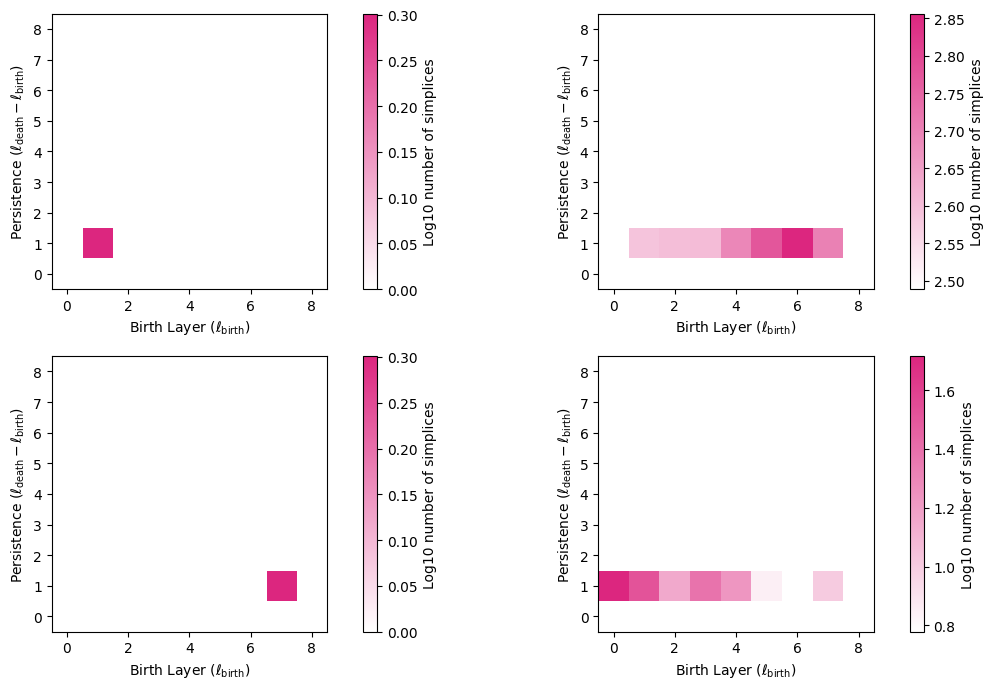

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_persistence_image(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/persistence_image.png")
fig.savefig(f"{dumper.directory_}/persistence_image.svg")

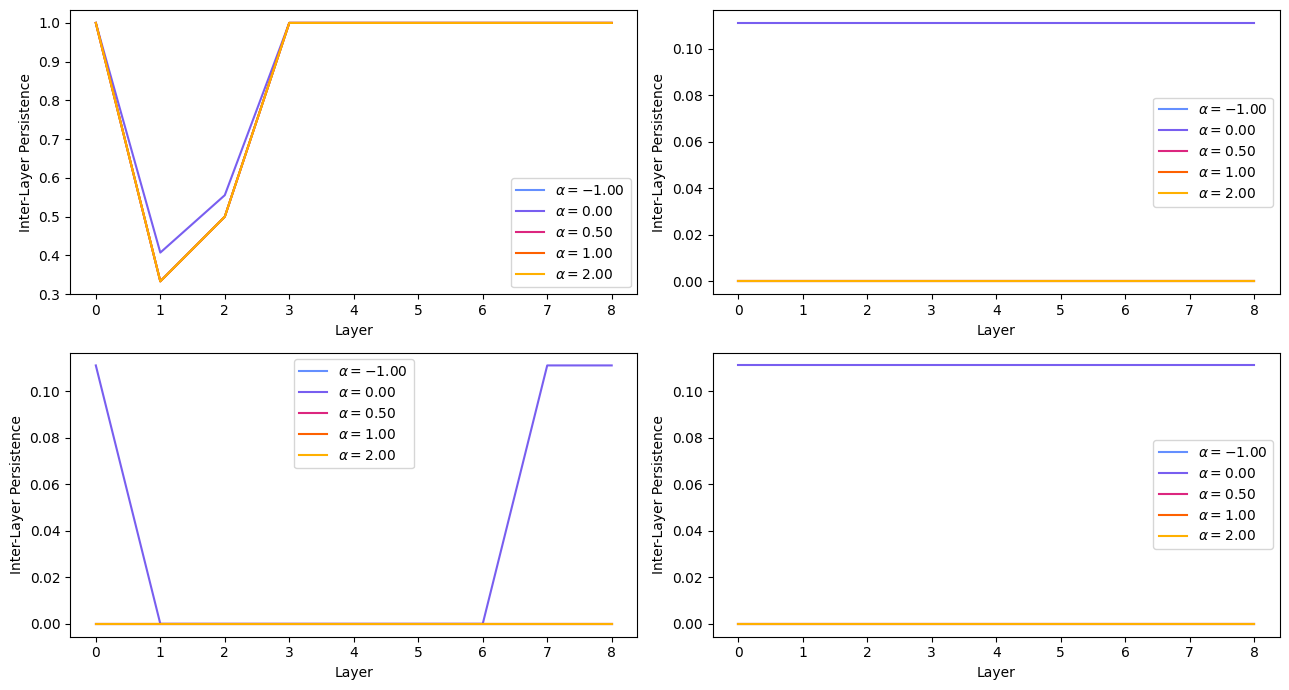

In [17]:
fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_weighted_inter_layer_persistence(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/inter_layer_persistence.png")
fig.savefig(f"{dumper.directory_}/inter_layer_persistence.svg")

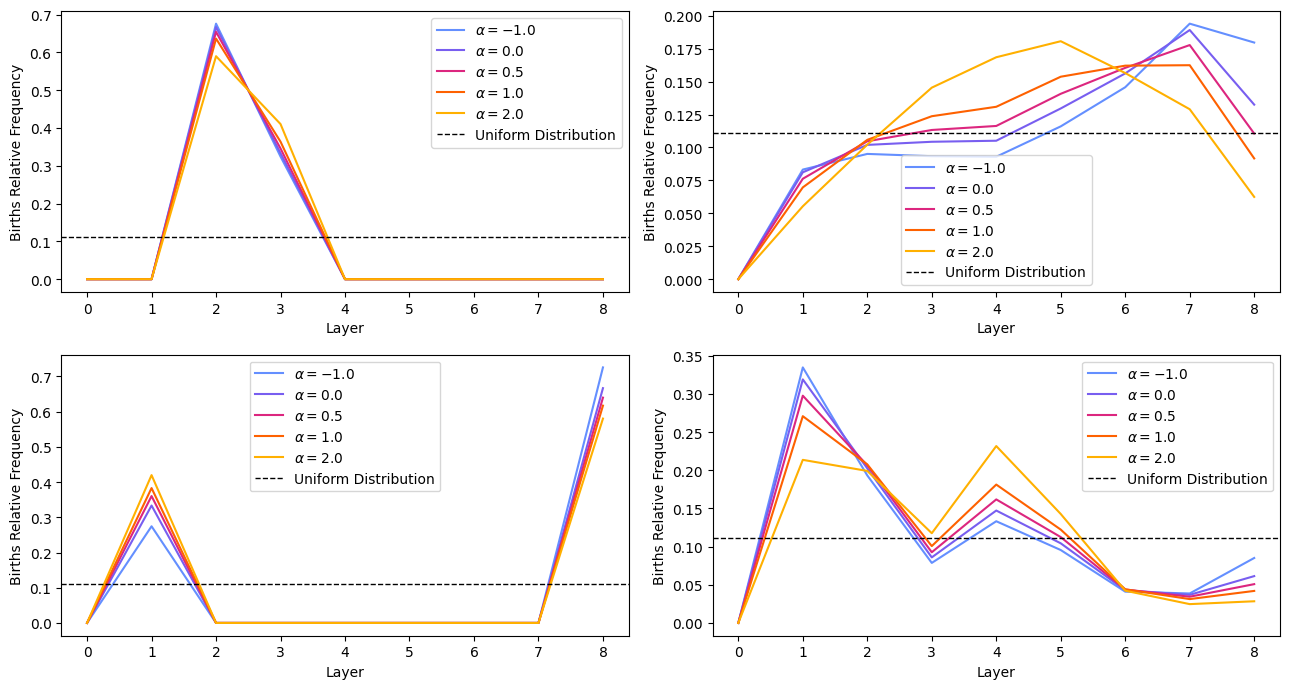

In [18]:
fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_births_relative_frequency(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/births_relative_frequency.png")
fig.savefig(f"{dumper.directory_}/births_relative_frequency.svg")

In [14]:
persistence_diagrams = dumper.execute(
    zigzag.topology.make_cubical_persistence,
    "persistence_diagrams",
    hidden_states
)

Got the result from mnist/resnet_small/persistence_diagrams
Got the result from mnist/resnet_small/persistence_diagrams/0.npy
Got the result from mnist/resnet_small/persistence_diagrams/1.npy
Got the result from mnist/resnet_small/persistence_diagrams/2.npy
Got the result from mnist/resnet_small/persistence_diagrams/3.npy
Got the result from mnist/resnet_small/persistence_diagrams/4.npy
Got the result from mnist/resnet_small/persistence_diagrams/5.npy
Got the result from mnist/resnet_small/persistence_diagrams/6.npy
Got the result from mnist/resnet_small/persistence_diagrams/7.npy
Got the result from mnist/resnet_small/persistence_diagrams/8.npy


In [30]:
import tqdm
import cvtda.logging
import cvtda.topology
import sklearn.preprocessing

def pds_to_vectors(pds):
    with cvtda.logging.DevNullLogger():
        dv = cvtda.topology.DiagramVectorizer(settings=cvtda.topology.DiagramVectorizer.PRESETS.full)
        ss = sklearn.preprocessing.StandardScaler()
        return ss.fit_transform(dv.fit_transform(pds))

vecs = [pds_to_vectors(pds) for pds in tqdm.tqdm(persistence_diagrams)]

100%|██████████| 9/9 [00:59<00:00,  6.65s/it]


In [31]:
knn_graphs = dumper.execute(
    zigzag.topology.make_knn_graphs_vector,
    "vector_pds_full/knn_graphs",
    vecs,
    k_neighbors=K_NEIGHBORS
)
diagrams = dumper.execute(
    zigzag.topology.compute_zigzag_barcodes,
    "vector_pds_full/diagrams",
    knn_graphs,
    dimension=MAX_DIMENSION
)

KNN graphs: 100%|██████████| 9/9 [00:00<00:00, 126.71it/s]


Saving the result to mnist/resnet_small/vector_pds_full/knn_graphs
Saving the result to mnist/resnet_small/vector_pds_full/knn_graphs/0.npz
Saving the result to mnist/resnet_small/vector_pds_full/knn_graphs/1.npz
Saving the result to mnist/resnet_small/vector_pds_full/knn_graphs/2.npz
Saving the result to mnist/resnet_small/vector_pds_full/knn_graphs/3.npz
Saving the result to mnist/resnet_small/vector_pds_full/knn_graphs/4.npz
Saving the result to mnist/resnet_small/vector_pds_full/knn_graphs/5.npz
Saving the result to mnist/resnet_small/vector_pds_full/knn_graphs/6.npz
Saving the result to mnist/resnet_small/vector_pds_full/knn_graphs/7.npz
Saving the result to mnist/resnet_small/vector_pds_full/knn_graphs/8.npz


Generate simplex tree: 100%|██████████| 9/9 [00:00<00:00, 72.61it/s]


[======================================================================] 100%
Saving the result to mnist/resnet_small/vector_pds_full/diagrams
Saving the result to mnist/resnet_small/vector_pds_full/diagrams/0.npy
Saving the result to mnist/resnet_small/vector_pds_full/diagrams/1.npy
Saving the result to mnist/resnet_small/vector_pds_full/diagrams/2.npy
Saving the result to mnist/resnet_small/vector_pds_full/diagrams/3.npy


/Users/abramov-alex/Desktop/HSE/CourseProject-Mag-1/zigzag/topology/plotting.py:45: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow(numpy.log10(pis_pers), cmap=CMAP, origin="lower")


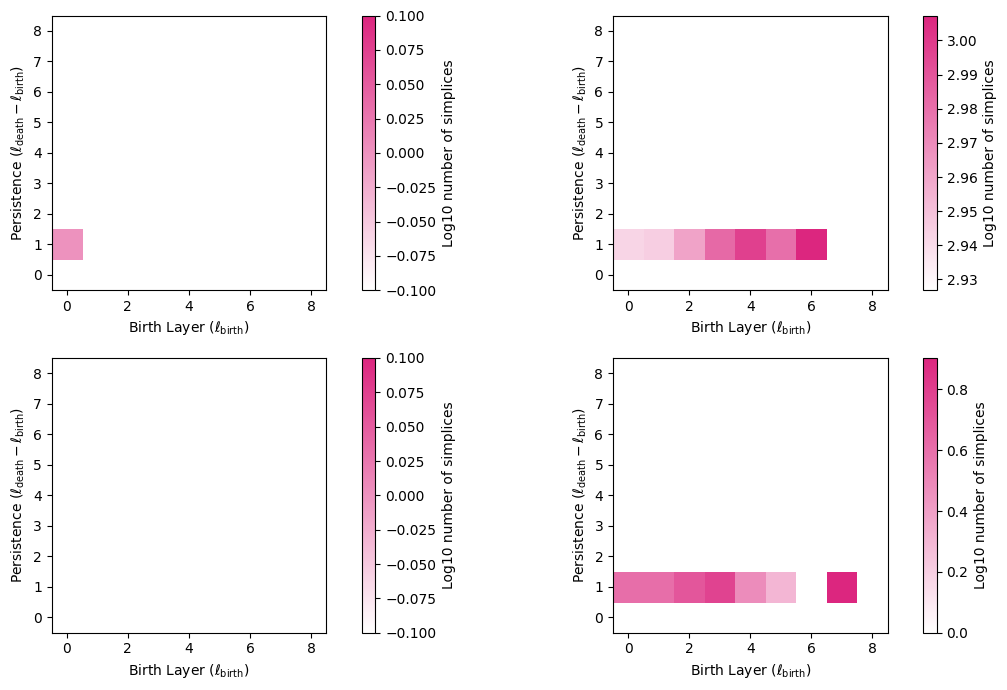

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_persistence_image(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/persistence_image.png")
fig.savefig(f"{dumper.directory_}/persistence_image.svg")

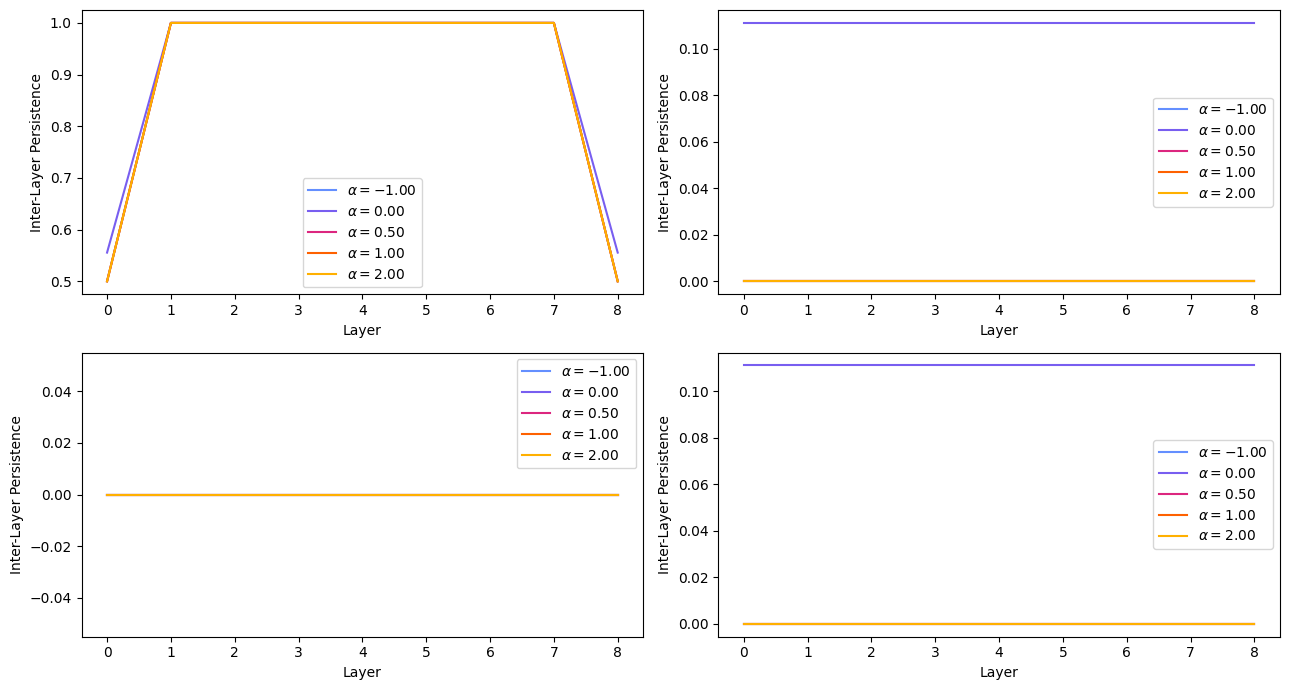

In [33]:
fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_weighted_inter_layer_persistence(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/inter_layer_persistence.png")
fig.savefig(f"{dumper.directory_}/inter_layer_persistence.svg")

/Users/abramov-alex/Desktop/HSE/CourseProject-Mag-1/zigzag/topology/metrics.py:80: RuntimeWarning: invalid value encountered in divide
  return result / numpy.sum(result)


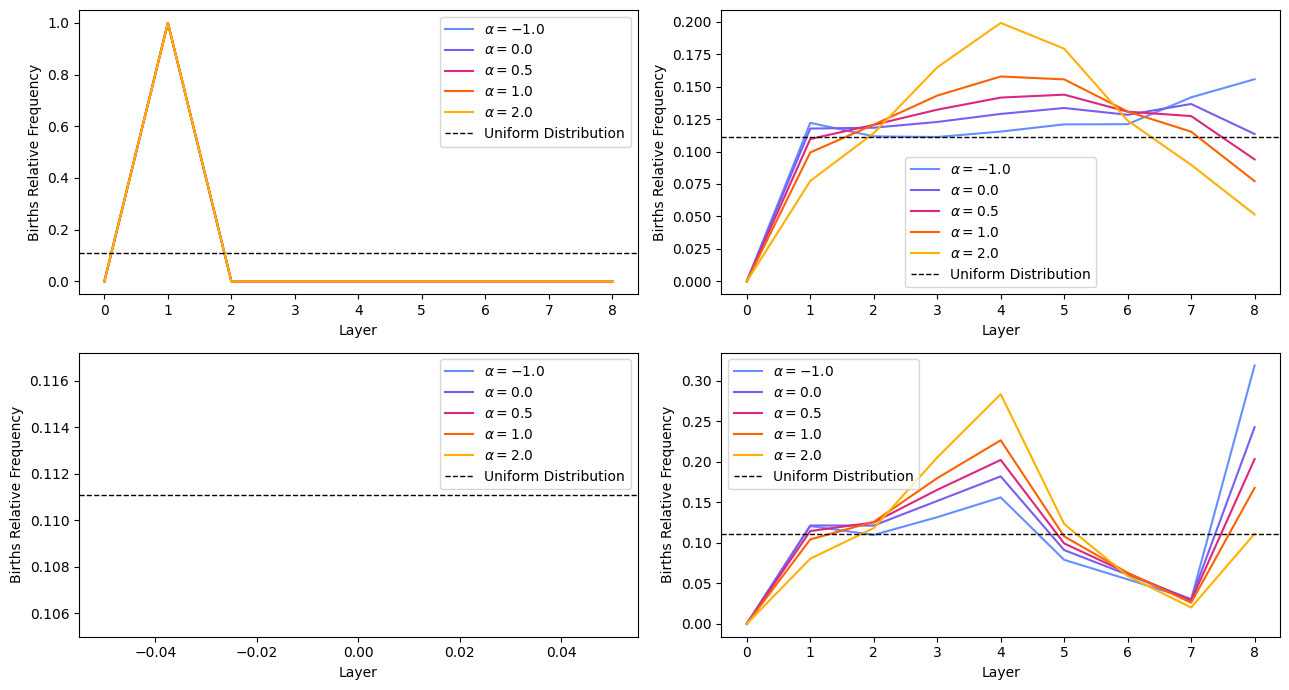

In [34]:
fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_births_relative_frequency(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/births_relative_frequency.png")
fig.savefig(f"{dumper.directory_}/births_relative_frequency.svg")

In [ ]:
import gtda.homology
import gtda.diagrams
import tqdm
import numpy
import sklearn.neighbors

import warnings
warnings.filterwarnings("ignore")

def to_vec(hs):
    res = []
    for i in range(hs.shape[1]):
        diagrams = gtda.homology.CubicalPersistence(n_jobs=-1).fit_transform(hs[:, i, :, :])
        res.append(gtda.diagrams.PairwiseDistance(metric='landscape', n_jobs=-1).fit_transform(diagrams))

        diagrams = gtda.homology.CubicalPersistence(n_jobs=-1).fit_transform(-hs[:, i, :, :])
        res.append(gtda.diagrams.PairwiseDistance(metric='landscape', n_jobs=-1).fit_transform(diagrams))
    return sklearn.neighbors.kneighbors_graph(
        numpy.linalg.norm(numpy.stack(res), axis=0),
        n_neighbors=K_NEIGHBORS,
        metric="precomputed",
        n_jobs=-1,
    )

knn_graphs = [to_vec(hs) for hs in tqdm.tqdm(hidden_states)]

In [12]:
import gtda.homology
import gtda.diagrams
import tqdm
import numpy
import sklearn.neighbors
import cvtda.topology
import cvtda.logging
import joblib

def vectorizer(images, dump_name):
    fe = cvtda.topology.FeatureExtractor(
        n_jobs=1,
        settings=cvtda.topology.FeatureExtractor.Settings(
            greyscale=cvtda.topology.GreyscaleExtractor.PRESETS.reduced,
            inverted=cvtda.topology.GreyscaleExtractor.PRESETS.reduced,
            filtrations=cvtda.topology.FiltrationsExtractor.Settings(binarizer_thresholds=[]),
            point_clouds=cvtda.topology.PointCloudsExtractor.Settings(enabled=False),
            geometry=cvtda.topology.GeometryExtractor.Settings(
                gray=cvtda.topology.GrayGeometryExtractor.Settings(
                    daisy=False,
                    sift=False,
                    orb=False,
                    basic=False,
                    curvature=False
                )
            ),
        )
    )
    maxi = images.max()
    mini = images.min()
    if maxi != mini:
        data = (images - mini) / (maxi - mini)
    else:
        return None
    with cvtda.logging.DevNullLogger():
        return fe.fit_transform(data.numpy(), dump_name=dump_name)

def to_vec(hs: torch.Tensor, dump_name):
    if hs.shape[2] < 16:
        return hs.flatten(start_dim=1).numpy()
    res = joblib.Parallel(n_jobs=-1)(
        joblib.delayed(vectorizer)(hs[:, i, :, :], f"{dump_name}/{i}")
        for i in tqdm.trange(hs.shape[1])
    )
    return numpy.hstack([item for item in res if item is not None])

vecs = [to_vec(hs, f"vectorizer/{i}") for i, hs in enumerate(hidden_states)]

100%|██████████| 128/128 [00:39<00:00,  3.21it/s]


In [13]:
import zigzag.topology

knn_graphs = dumper.execute(
    zigzag.topology.make_knn_graphs_vector,
    "vectorizer/knn_graphs",
    vecs,
    k_neighbors=K_NEIGHBORS
)
diagrams = dumper.execute(
    zigzag.topology.compute_zigzag_barcodes,
    "vectorizer/diagrams",
    knn_graphs,
    dimension=MAX_DIMENSION
)

KNN graphs: 100%|██████████| 9/9 [00:19<00:00,  2.20s/it]


Saving the result to mnist/resnet_small/vectorizer/knn_graphs
Saving the result to mnist/resnet_small/vectorizer/knn_graphs/0.npz
Saving the result to mnist/resnet_small/vectorizer/knn_graphs/1.npz
Saving the result to mnist/resnet_small/vectorizer/knn_graphs/2.npz
Saving the result to mnist/resnet_small/vectorizer/knn_graphs/3.npz
Saving the result to mnist/resnet_small/vectorizer/knn_graphs/4.npz
Saving the result to mnist/resnet_small/vectorizer/knn_graphs/5.npz
Saving the result to mnist/resnet_small/vectorizer/knn_graphs/6.npz
Saving the result to mnist/resnet_small/vectorizer/knn_graphs/7.npz
Saving the result to mnist/resnet_small/vectorizer/knn_graphs/8.npz


Generate simplex tree: 100%|██████████| 9/9 [00:00<00:00, 50.46it/s]


[======================================================================] 100%
Saving the result to mnist/resnet_small/vectorizer/diagrams
Saving the result to mnist/resnet_small/vectorizer/diagrams/0.npy
Saving the result to mnist/resnet_small/vectorizer/diagrams/1.npy
Saving the result to mnist/resnet_small/vectorizer/diagrams/2.npy
Saving the result to mnist/resnet_small/vectorizer/diagrams/3.npy


/Users/abramov-alex/Desktop/HSE/CourseProject-Mag-1/zigzag/topology/plotting.py:45: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow(numpy.log10(pis_pers), cmap=CMAP, origin="lower")


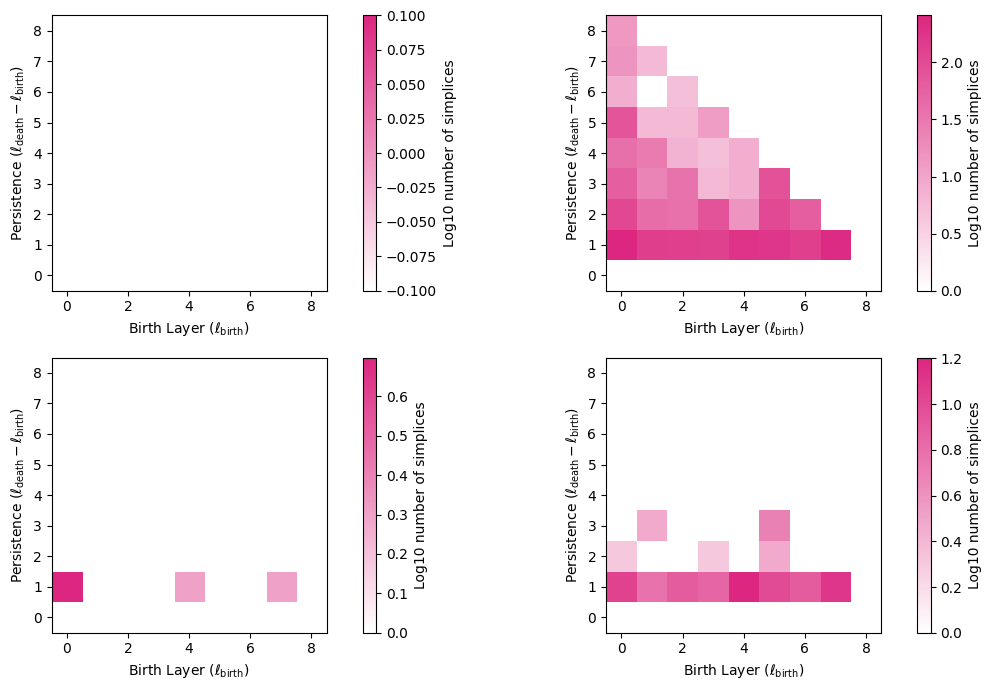

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_persistence_image(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/persistence_image.png")
fig.savefig(f"{dumper.directory_}/persistence_image.svg")

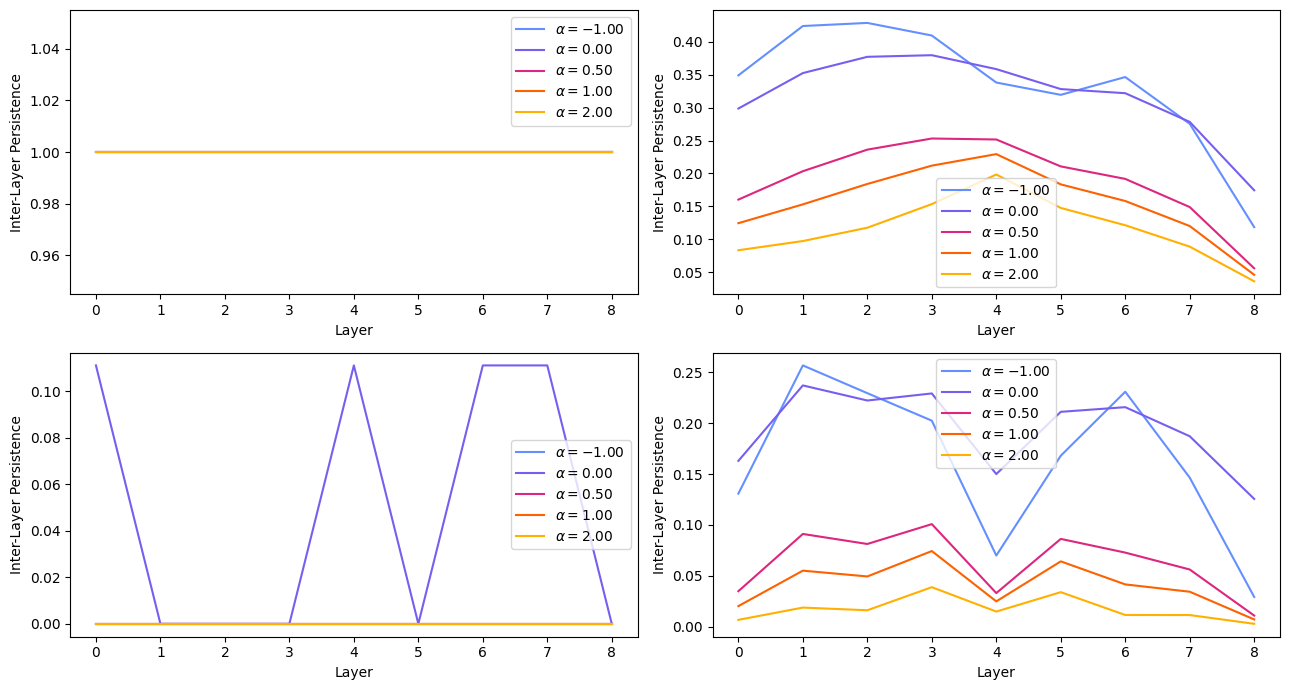

In [15]:
fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_weighted_inter_layer_persistence(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/inter_layer_persistence.png")
fig.savefig(f"{dumper.directory_}/inter_layer_persistence.svg")

/Users/abramov-alex/Desktop/HSE/CourseProject-Mag-1/zigzag/topology/metrics.py:80: RuntimeWarning: invalid value encountered in divide
  return result / numpy.sum(result)


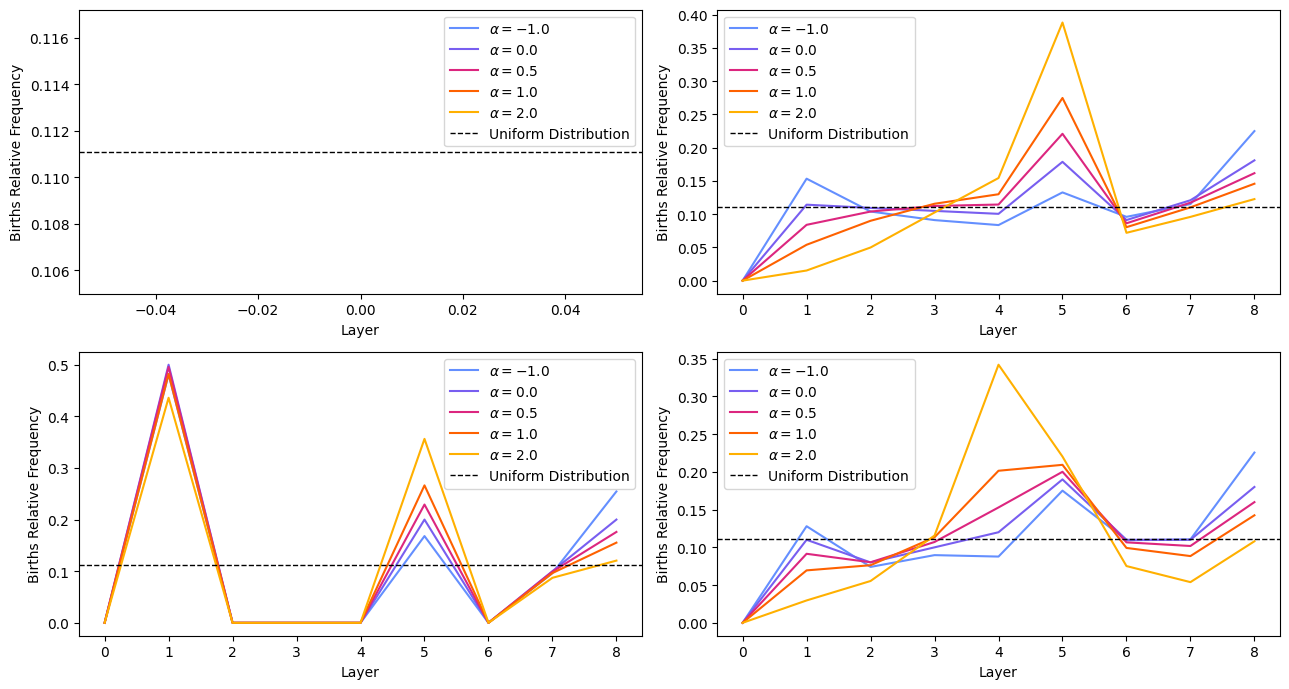

In [16]:
fig, axes = plt.subplots(2, 2, figsize = (13, 7))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_births_relative_frequency(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/births_relative_frequency.png")
fig.savefig(f"{dumper.directory_}/births_relative_frequency.svg")